# 05: Choropleth Maps

This notebook demonstrates choropleth map creation using `siege_utilities.geo.choropleth`:

1. **Simple Choropleths** — `create_choropleth()` for single-variable maps
2. **Multi-Variable Comparison** — `create_choropleth_comparison()` for side-by-side maps
3. **Classification Schemes** — `create_classified_comparison()` with quantiles, equal interval, etc.
4. **Bivariate Choropleths** — `create_bivariate_choropleth()` for two variables simultaneously
5. **Saving Maps** — `save_map()` for export to PNG/PDF/SVG

## Prerequisites

```bash
pip install -e /path/to/siege_utilities[geo]
# mapclassify is included in the geo extras for classification schemes
```

In [1]:
%matplotlib inline

# Imports
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import siege_utilities as su
from siege_utilities.geo import get_census_boundaries
from siege_utilities.geo.choropleth import (
    create_choropleth,
    create_choropleth_comparison,
    create_classified_comparison,
    create_bivariate_choropleth,
    create_bivariate_crosstab,
    create_bivariate_companion_maps,
    verify_bivariate_classification,
    create_bivariate_analysis,
    BivariateAnalysisResult,
    save_map,
    BIVARIATE_COLOR_SCHEMES,
    SCHEME_LABELS,
)

import numpy as np
import matplotlib.pyplot as plt

# Initialize logging
su.configure_shared_logging(level="INFO")

# Set random seed for reproducibility
np.random.seed(42)

su.log_info("Imports successful!")
su.log_info(f"Available bivariate color schemes: {list(BIVARIATE_COLOR_SCHEMES.keys())}")
su.log_info(f"Available classification schemes: {list(SCHEME_LABELS.keys())}")

# --- Output configuration ---
OUTPUT_DIR = Path("output") / "notebook_05"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# --- Branding configuration ---
from siege_utilities.reporting.client_branding import ClientBrandingManager
_branding_mgr = ClientBrandingManager()
BRANDING = _branding_mgr.get_client_branding('siege_analytics')
COLORS = BRANDING['colors']

su.log_info(f"Output directory: {OUTPUT_DIR}  (exists={OUTPUT_DIR.exists()})")
su.log_info(f"Branding: {BRANDING['name']} (primary={COLORS['primary']})")

[siege_utilities] 2026-02-21 17:43:43,816 WARNING: Could not create directory /Users/dheerajchand/Documents/Professional/Siege_Analytics/Code/siege_utilities/data: [Errno 13] Permission denied: '/Users'


[siege_utilities] 2026-02-21 17:43:43,818 WARNING: Could not create directory /Users/dheerajchand/Documents/Professional/Siege_Analytics/Code/siege_utilities/data/census: [Errno 13] Permission denied: '/Users'


[siege_utilities] 2026-02-21 17:43:43,818 WARNING: Could not create directory /Users/dheerajchand/Documents/Professional/Siege_Analytics/Code/siege_utilities/data/nces: [Errno 13] Permission denied: '/Users'


[siege_utilities] 2026-02-21 17:43:43,819 WARNING: Could not create directory /Users/dheerajchand/Documents/Professional/Siege_Analytics/Code/siege_utilities/data/samples: [Errno 13] Permission denied: '/Users'


[siege_utilities] 2026-02-21 17:43:44,118 INFO: Importing spark_utils from siege_utilities.distributed.spark_utils


...

[siege_utilities] 2026-02-21 17:43:59,570 INFO: Imports successful!


[siege_utilities] 2026-02-21 17:43:59,570 INFO: Available bivariate color schemes: ['purple_blue', 'teuling', 'blue_red', 'green_orange']


[siege_utilities] 2026-02-21 17:43:59,571 INFO: Available classification schemes: ['quantiles', 'equal_interval', 'fisher_jenks', 'natural_breaks', 'percentiles', 'std_mean', 'max_p', 'boxplot', 'headtailbreaks']


[siege_utilities] 2026-02-21 17:43:59,572 INFO: Output directory: output/notebook_05  (exists=True)


[siege_utilities] 2026-02-21 17:43:59,573 INFO: Branding: Siege Analytics (primary=#1D365D)


## 1. Load Geographic Data

We'll use California counties as our base geography.

In [2]:
# Download California counties
counties = get_census_boundaries(year=2020, geographic_level='county', state_fips='06')
ca_counties = counties[counties['statefp'] == '06'].copy()

su.log_info(f"Loaded {len(ca_counties)} California counties")
su.log_info(f"Columns: {list(ca_counties.columns)[:8]}...")

[siege_utilities] 2026-02-21 17:44:35,433 INFO: Initialized Census data source with 23 available years


[siege_utilities] 2026-02-21 17:44:35,603 INFO: Constructed URL: https://www2.census.gov/geo/tiger/TIGER2020/COUNTY/tl_2020_us_county.zip


[siege_utilities] 2026-02-21 17:44:35,720 INFO: Downloading county boundaries for year 2020


[siege_utilities] 2026-02-21 17:44:35,721 INFO: Downloading TIGER/Line data from: https://www2.census.gov/geo/tiger/TIGER2020/COUNTY/tl_2020_us_county.zip


[siege_utilities] 2026-02-21 17:44:35,723 INFO: Ensured path exists: /home/dheerajchand/Downloads/siege_utilities


...

[siege_utilities] 2026-02-21 17:44:37,741 INFO: Extracted /home/dheerajchand/Downloads/siege_utilities/tl_2020_us_county.zip to /home/dheerajchand/Downloads/siege_utilities/tl_2020_us_county


[siege_utilities] 2026-02-21 17:44:38,217 INFO: Successfully processed county boundaries: 3234 features


[siege_utilities] 2026-02-21 17:44:38,222 INFO: Filtered county from 3234 to 58 features for state 06


[siege_utilities] 2026-02-21 17:44:38,223 INFO: Loaded 58 California counties


[siege_utilities] 2026-02-21 17:44:38,224 INFO: Columns: ['statefp', 'countyfp', 'countyns', 'geoid', 'name', 'namelsad', 'lsad', 'classfp']...


In [3]:
# Create sample data - simulated population and income
ca_counties['population'] = np.random.randint(10000, 10000000, size=len(ca_counties))
ca_counties['median_income'] = np.random.randint(40000, 150000, size=len(ca_counties))
ca_counties['unemployment_rate'] = np.random.uniform(2.0, 15.0, size=len(ca_counties))

# Calculate area in square miles
ca_counties['area_sq_mi'] = ca_counties['aland'] / 2_589_988
ca_counties['pop_density'] = ca_counties['population'] / ca_counties['area_sq_mi']

su.log_info("Sample data:")
su.log_info(str(ca_counties[['name', 'population', 'median_income', 'unemployment_rate']].head()))

[siege_utilities] 2026-02-21 17:44:38,233 INFO: Sample data:


[siege_utilities] 2026-02-21 17:44:38,237 INFO:               name  population  median_income  unemployment_rate
8           Sierra     6433388         111211          10.656991
325     Sacramento     6560634         105697           9.686871
329  Santa Barbara     4314572          77065           5.571383
346      Calaveras     2244489         132093           9.296165
394        Ventura     9968614         139299           6.978049


## 2. Simple Choropleth with GeoPandas

The most straightforward way to create a choropleth using GeoDataFrame.plot()

[siege_utilities] 2026-02-21 17:44:38,537 INFO: Map saved to: output/notebook_05/choropleth_population.png


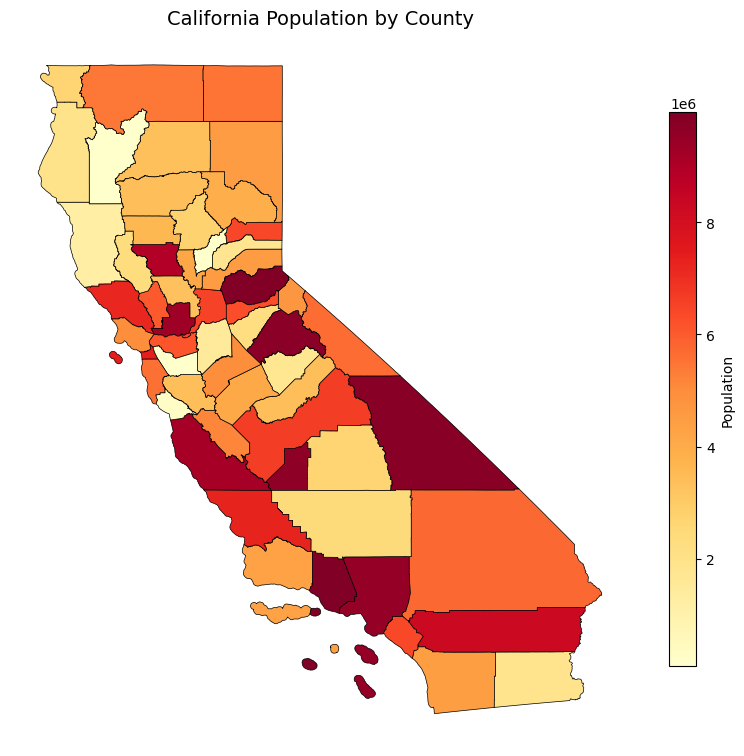

In [4]:
# Simple choropleth - population
fig, ax = create_choropleth(
    ca_counties,
    column='population',
    title='California Population by County',
    cmap='YlOrRd',
    legend_kwds={'label': 'Population', 'shrink': 0.6},
)
save_map(fig, str(OUTPUT_DIR / 'choropleth_population.png'))
plt.show()
plt.close()

[siege_utilities] 2026-02-21 17:44:39,732 INFO: Map saved to: output/notebook_05/comparison_3panel.png


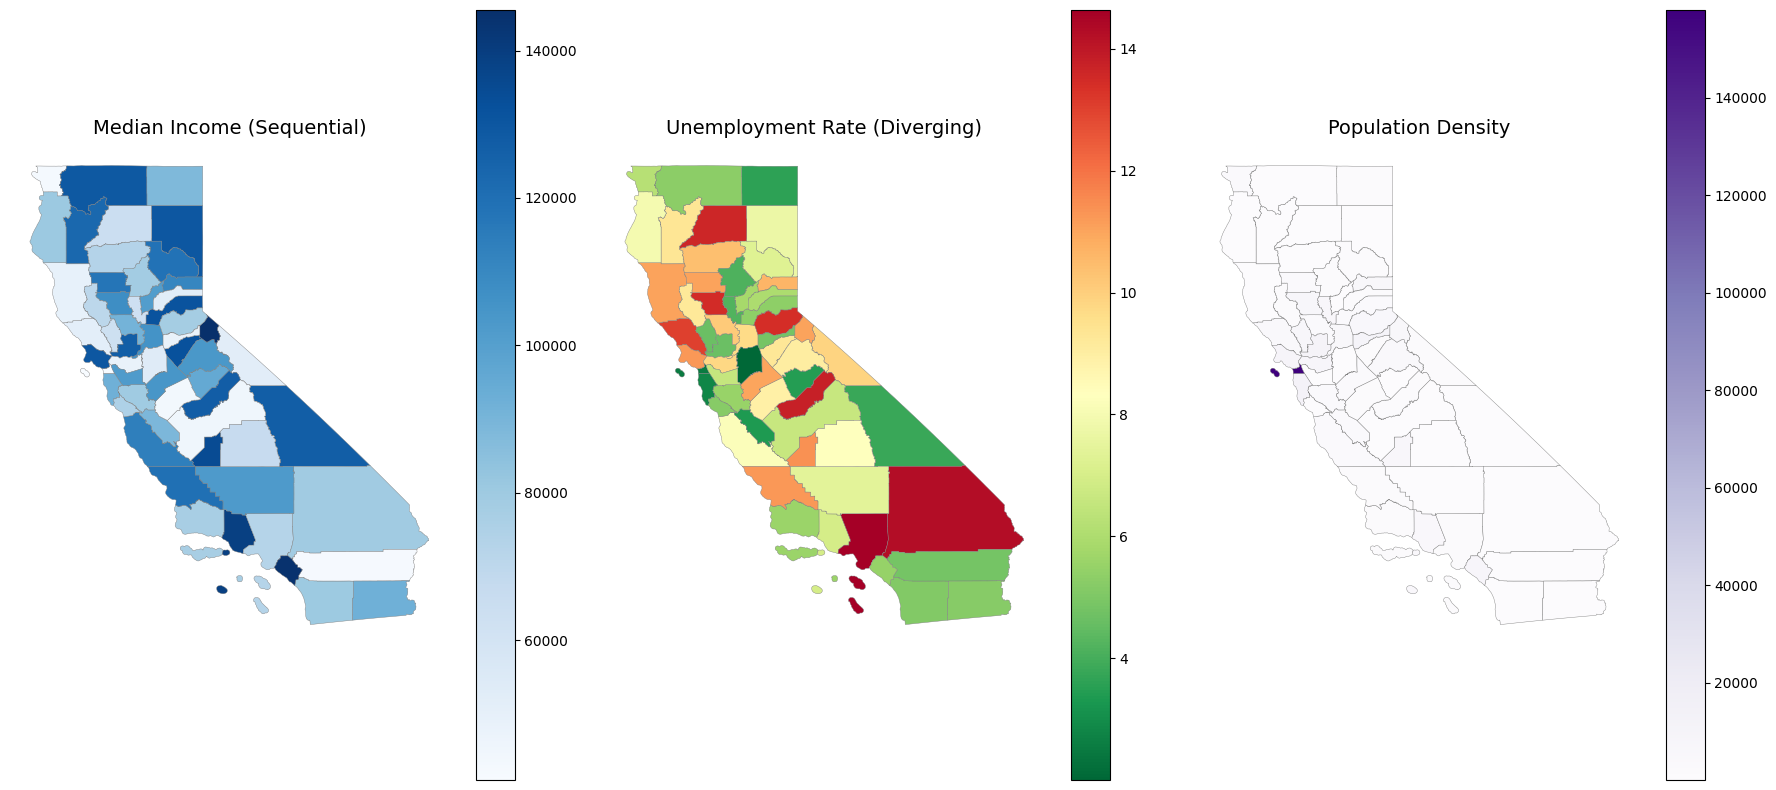

In [5]:
# Compare multiple variables side by side
fig, axes = create_choropleth_comparison(
    ca_counties,
    columns=[
        {'column': 'median_income', 'title': 'Median Income (Sequential)', 'cmap': 'Blues'},
        {'column': 'unemployment_rate', 'title': 'Unemployment Rate (Diverging)', 'cmap': 'RdYlGn_r'},
        {'column': 'pop_density', 'title': 'Population Density', 'cmap': 'Purples'},
    ],
    figsize=(18, 8),
    ncols=3,
)
save_map(fig, str(OUTPUT_DIR / 'comparison_3panel.png'))
plt.show()
plt.close()

## 3. Classification Schemes

Different ways to bin continuous data for choropleth maps.

[siege_utilities] 2026-02-21 17:44:41,662 INFO: Map saved to: output/notebook_05/classified_comparison.png


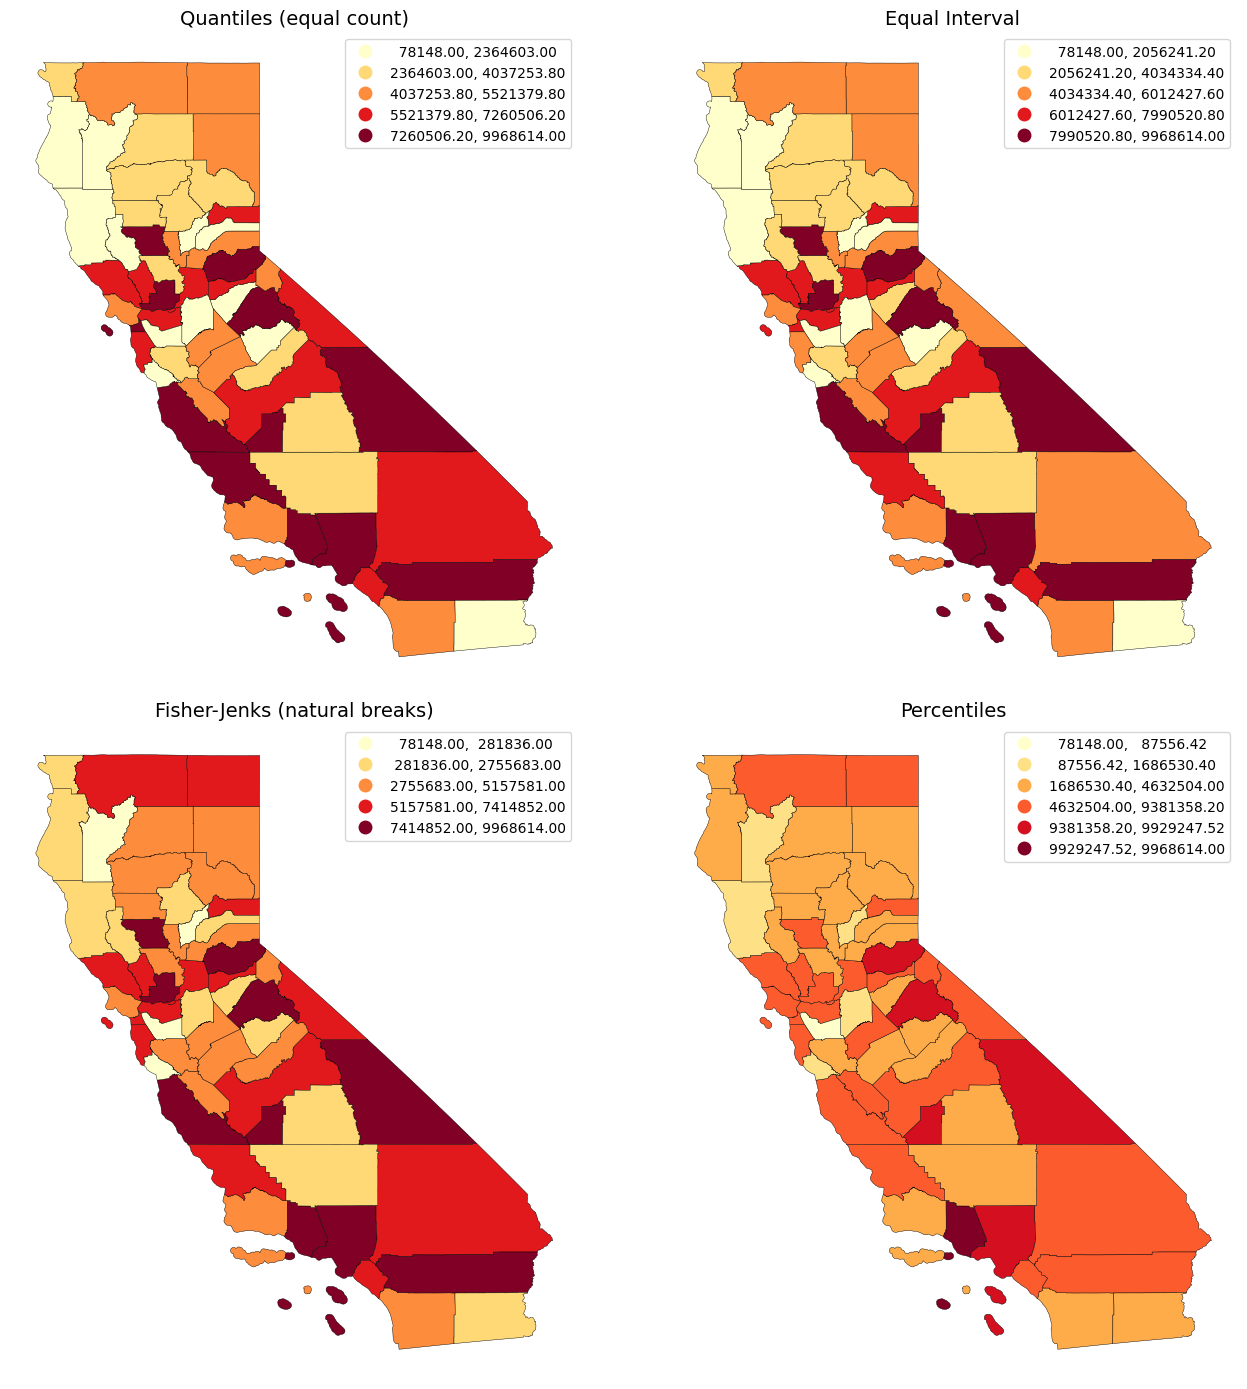

In [6]:
# Compare classification schemes for population
fig, axes = create_classified_comparison(
    ca_counties,
    column='population',
    schemes=['quantiles', 'equal_interval', 'fisher_jenks', 'percentiles'],
    k=5,
    cmap='YlOrRd',
    figsize=(14, 14),
    ncols=2,
)
save_map(fig, str(OUTPUT_DIR / 'classified_comparison.png'))
plt.show()
plt.close()

## 4. Bivariate Choropleth

Show two variables simultaneously using a 2D color scheme.

[siege_utilities] 2026-02-21 17:44:42,510 INFO: Map saved to: output/notebook_05/bivariate_pop_income.png


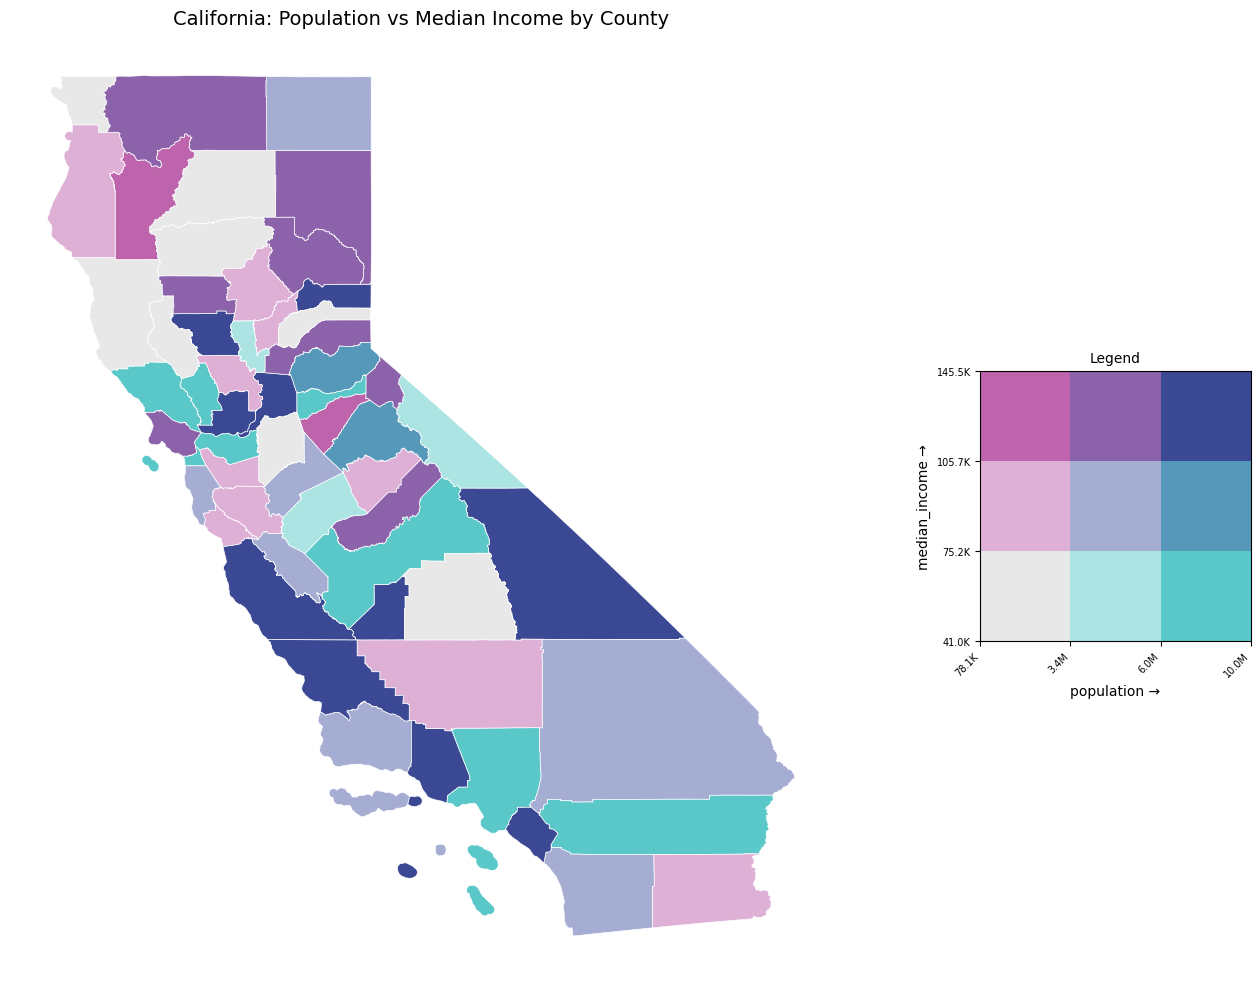

In [7]:
# Bivariate choropleth: Population vs Median Income
fig, axes = create_bivariate_choropleth(
    ca_counties,
    var1='population',
    var2='median_income',
    title='California: Population vs Median Income by County',
)
save_map(fig, str(OUTPUT_DIR / 'bivariate_pop_income.png'))
plt.show()
plt.close()

[siege_utilities] 2026-02-21 17:44:43,052 INFO: Map saved to: output/notebook_05/bivariate_density_unemployment.png


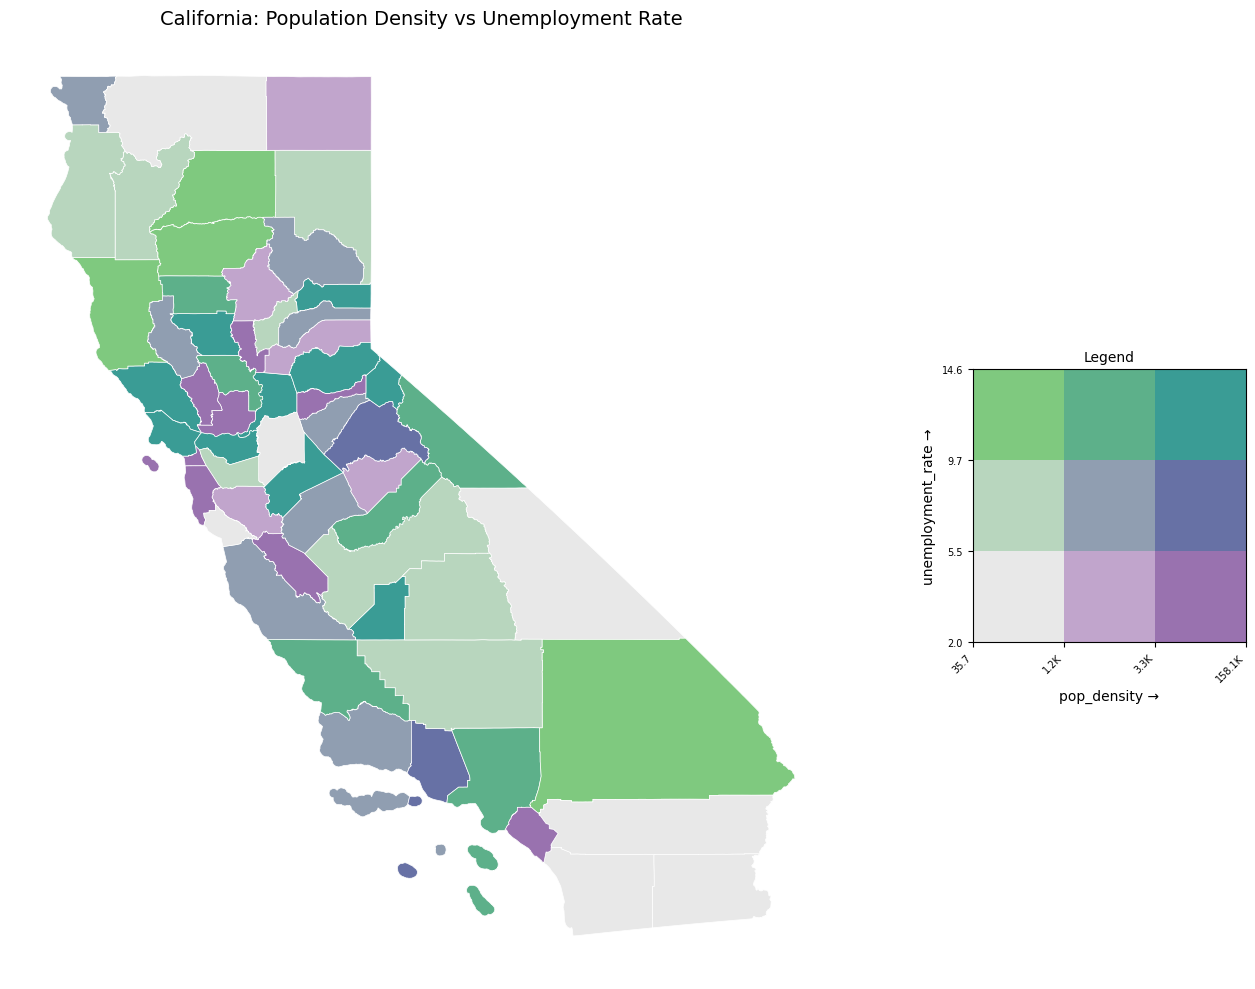

In [8]:
# Bivariate choropleth with a different color scheme
fig, axes = create_bivariate_choropleth(
    ca_counties,
    var1='pop_density',
    var2='unemployment_rate',
    title='California: Population Density vs Unemployment Rate',
    color_scheme='teuling',
)
save_map(fig, str(OUTPUT_DIR / 'bivariate_density_unemployment.png'))
plt.show()
plt.close()

## 4b. Bivariate Verification

The bivariate choropleth is powerful but hard to audit visually. These verification tools let you:

1. **Crosstab** — see how many geographic units fall in each class pair
2. **Companion maps** — see each variable independently with matching quantile bins
3. **Verification check** — confirm classification integrity (no missing units, monotonic breakpoints)
4. **Full analysis** — one call to produce all artifacts at once

[siege_utilities] 2026-02-21 17:44:43,316 INFO: Map saved to: output/notebook_05/bivariate_crosstab.png


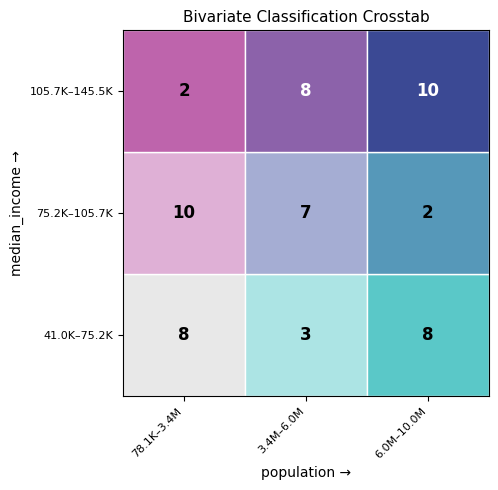

[siege_utilities] 2026-02-21 17:44:43,361 INFO: Bivariate crosstab (counts per class pair):


population,78.1K–3.4M,3.4M–6.0M,6.0M–10.0M
median_income,,,
41.0K–75.2K,8,3,8
75.2K–105.7K,10,7,2
105.7K–145.5K,2,8,10


In [9]:
# 4b-1: Crosstab — how many counties in each bivariate class pair?
# The rendered version colors cells to match the bivariate legend.
ct, ct_fig, ct_ax = create_bivariate_crosstab(
    ca_counties, 'population', 'median_income',
    render=True,
)
save_map(ct_fig, str(OUTPUT_DIR / 'bivariate_crosstab.png'))
plt.show()
plt.close()

# Also display the raw DataFrame
su.log_info("Bivariate crosstab (counts per class pair):")
display(ct)

[siege_utilities] 2026-02-21 17:44:43,978 INFO: Map saved to: output/notebook_05/bivariate_companion_maps.png


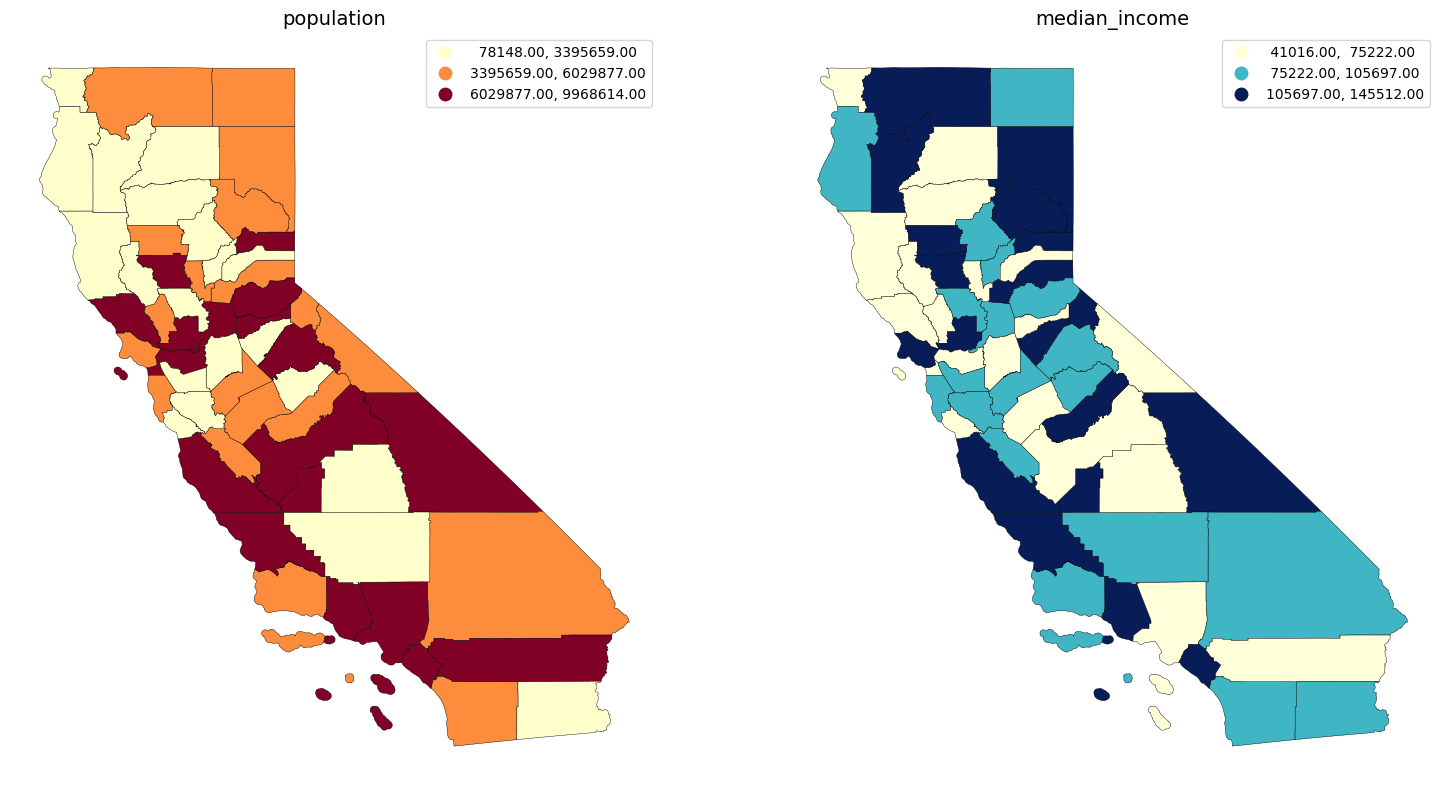

In [10]:
# 4b-2: Companion maps — each variable shown independently with same quantile bins
comp_fig, comp_axes = create_bivariate_companion_maps(
    ca_counties, 'population', 'median_income',
)
save_map(comp_fig, str(OUTPUT_DIR / 'bivariate_companion_maps.png'))
plt.show()
plt.close()

In [11]:
# 4b-3: Verification — confirm classification integrity
v = verify_bivariate_classification(
    ca_counties, 'population', 'median_income',
)

su.log_info(f"Classification valid: {v['valid']}")
su.log_info(f"Total units: {v['total_units']}")
su.log_info(f"Classified: {v['classified_units']}")
su.log_info(f"Var1 breakpoints: {v['var1_breaks']}")
su.log_info(f"Var2 breakpoints: {v['var2_breaks']}")
if v['errors']:
    for err in v['errors']:
        su.log_warning(f"  ERROR: {err}")
else:
    su.log_info("All checks passed!")

[siege_utilities] 2026-02-21 17:44:44,212 INFO: Classification valid: True


[siege_utilities] 2026-02-21 17:44:44,213 INFO: Total units: 58


[siege_utilities] 2026-02-21 17:44:44,213 INFO: Classified: 58


[siege_utilities] 2026-02-21 17:44:44,214 INFO: Var1 breakpoints: [  78148. 3395659. 6029877. 9968614.]


[siege_utilities] 2026-02-21 17:44:44,215 INFO: Var2 breakpoints: [ 41016.  75222. 105697. 145512.]


[siege_utilities] 2026-02-21 17:44:44,215 INFO: All checks passed!


[siege_utilities] 2026-02-21 17:44:45,155 INFO: Map saved to: output/notebook_05/analysis_bivariate.png


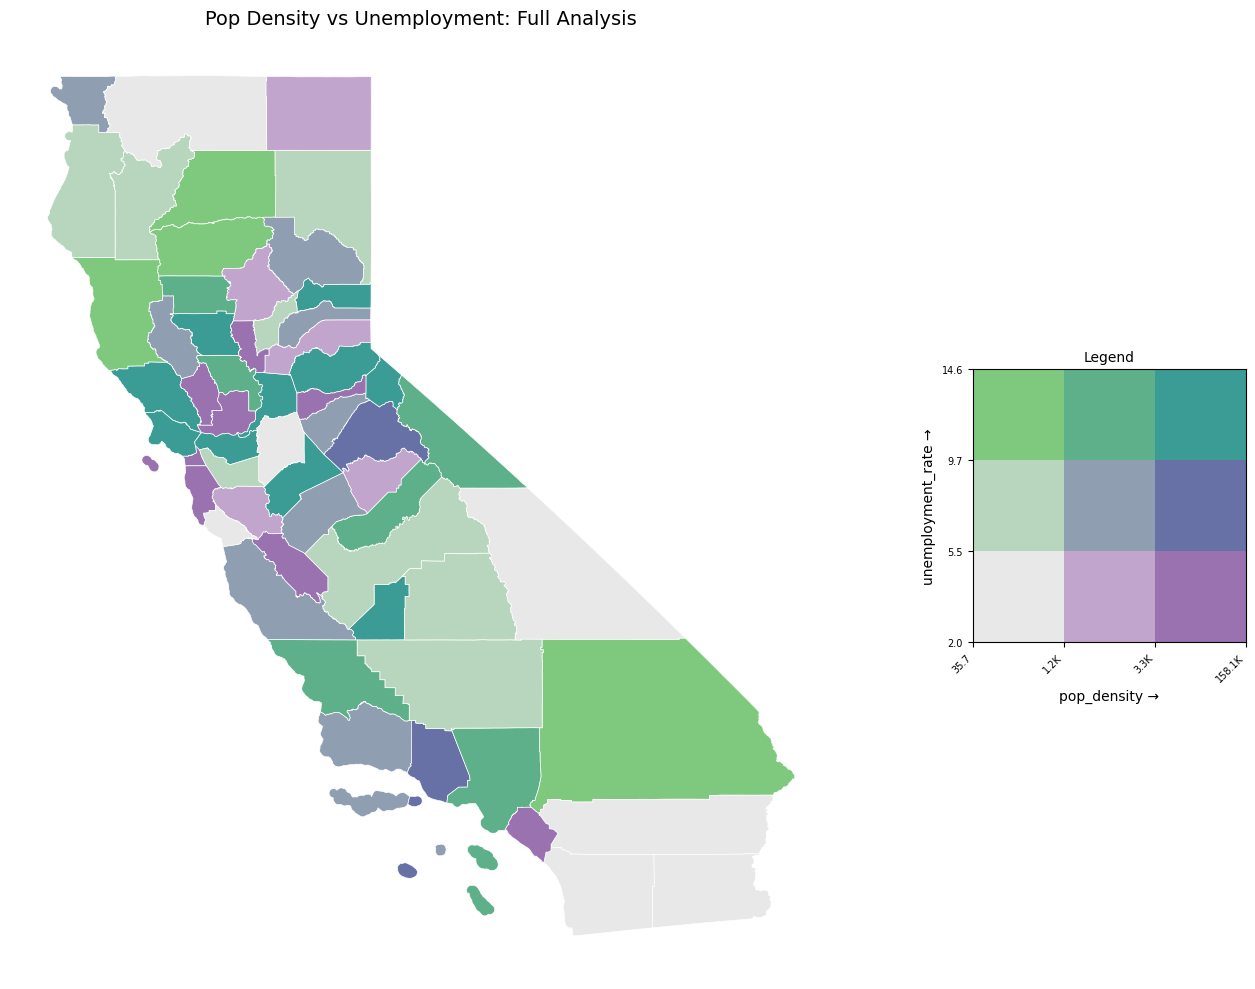

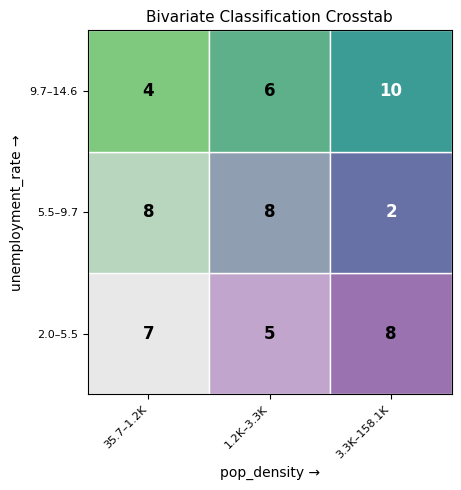

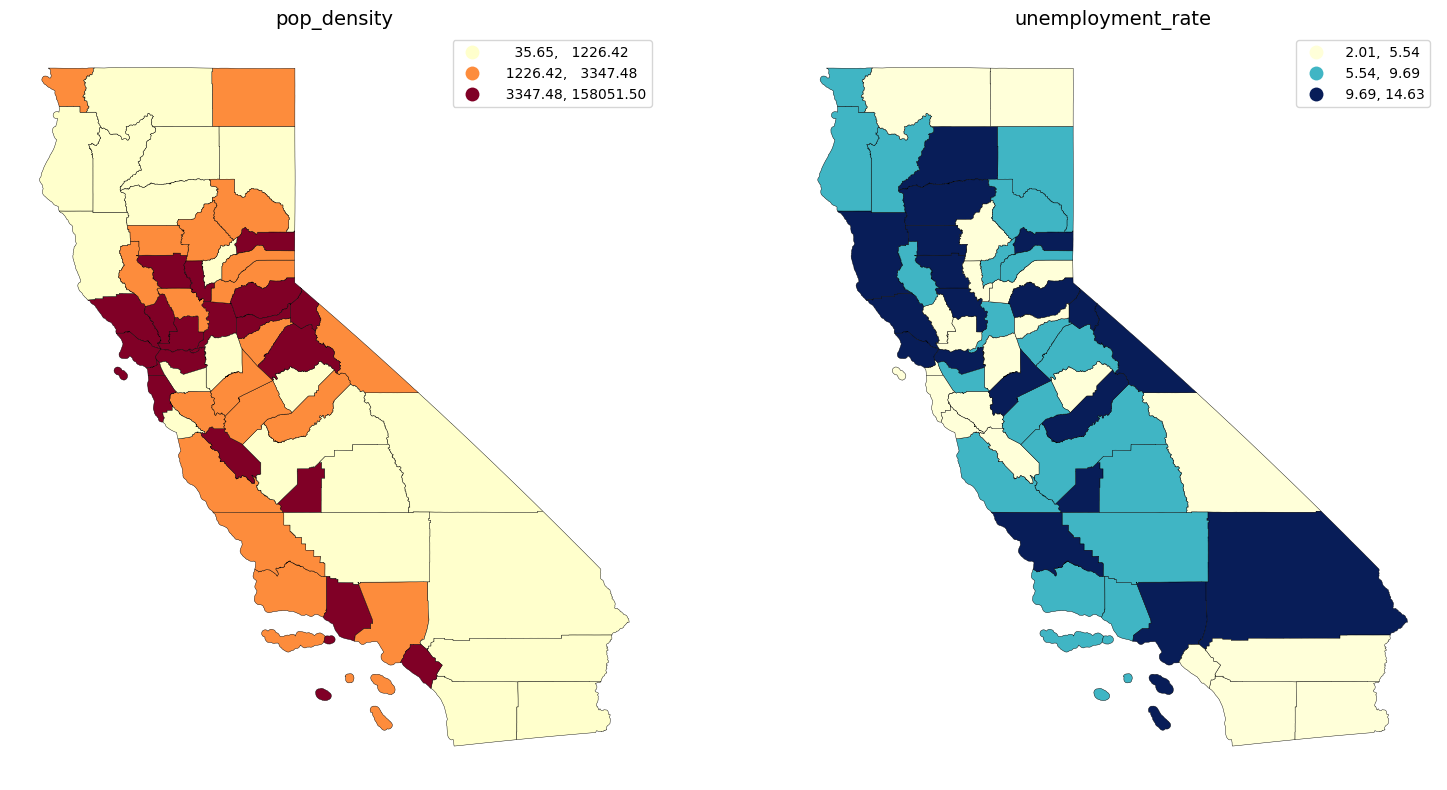

[siege_utilities] 2026-02-21 17:44:45,570 INFO: Crosstab:


pop_density,35.7–1.2K,1.2K–3.3K,3.3K–158.1K
unemployment_rate,,,
2.0–5.5,7,5,8
5.5–9.7,8,8,2
9.7–14.6,4,6,10


[siege_utilities] 2026-02-21 17:44:45,843 INFO: Map saved to: output/notebook_05/analysis_companion.png


[siege_utilities] 2026-02-21 17:44:45,844 INFO: Verification passed: True


[siege_utilities] 2026-02-21 17:44:45,845 INFO: Var1 breaks: [3.56544375e+01 1.22642361e+03 3.34748431e+03 1.58051500e+05]


[siege_utilities] 2026-02-21 17:44:45,845 INFO: Var2 breaks: [ 2.0067649   5.53771924  9.68687124 14.63225724]


In [12]:
# 4b-4: Full analysis — one call produces everything
result = create_bivariate_analysis(
    ca_counties, 'pop_density', 'unemployment_rate',
    title='Pop Density vs Unemployment: Full Analysis',
    color_scheme='teuling',
)

# Show the bivariate map (legend now includes magnitude tick labels)
save_map(result.bivariate_fig, str(OUTPUT_DIR / 'analysis_bivariate.png'))
plt.show()
plt.close(result.bivariate_fig)

# Show the crosstab
su.log_info("Crosstab:")
display(result.crosstab)

# Show companion maps
save_map(result.companion_fig, str(OUTPUT_DIR / 'analysis_companion.png'))
plt.show()
plt.close(result.companion_fig)

# Show verification
su.log_info(f"Verification passed: {result.verification['valid']}")
su.log_info(f"Var1 breaks: {result.var1_breaks}")
su.log_info(f"Var2 breaks: {result.var2_breaks}")

## 5. Using ChartGenerator

The ChartGenerator class provides choropleth methods designed for integration with the reporting system.

In [13]:
# Initialize ChartGenerator (from reporting module) with branding
try:
    from siege_utilities.reporting.chart_generator import ChartGenerator
    chart_gen = ChartGenerator(branding_config=BRANDING, output_dir=OUTPUT_DIR)

    # Prepare data for ChartGenerator (expects location column and value column)
    chart_data = ca_counties[['name', 'population', 'median_income']].copy()
    chart_data = chart_data.rename(columns={'name': 'county'})

    su.log_info(f"ChartGenerator initialized with {BRANDING['name']} branding")
    su.log_info("Available methods: create_choropleth_map, create_bivariate_choropleth")
except ImportError as e:
    su.log_warning(f"ChartGenerator not available: {e}")
    su.log_warning("Skipping ChartGenerator demos — install reporting extras if needed")

[siege_utilities] 2026-02-21 17:44:45,857 INFO: ChartGenerator initialized with Siege Analytics branding


[siege_utilities] 2026-02-21 17:44:45,857 INFO: Available methods: create_choropleth_map, create_bivariate_choropleth


In [14]:
# Check if Folium is available (required for ChartGenerator maps)
try:
    import folium
    HAS_FOLIUM = True
    su.log_info(f"Folium version: {folium.__version__}")
except ImportError:
    HAS_FOLIUM = False
    su.log_warning("Folium not available - ChartGenerator maps will use fallback")

[siege_utilities] 2026-02-21 17:44:45,864 INFO: Folium version: 0.20.0


## 6. Saving Maps

Export choropleth maps to various formats.

[siege_utilities] 2026-02-21 17:44:46,197 INFO: Map saved to: output/notebook_05/ca_income_choropleth.png


[siege_utilities] 2026-02-21 17:44:46,198 INFO: Saved to: output/notebook_05/ca_income_choropleth.png


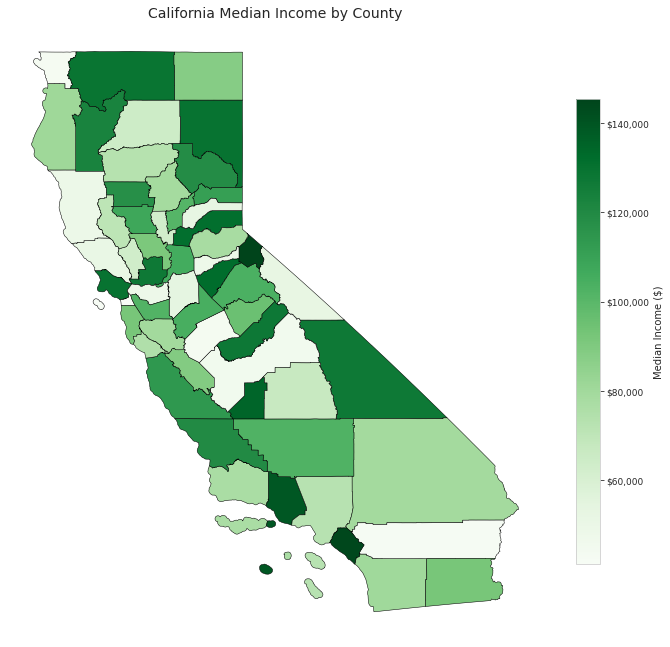

In [15]:
# Create and save a choropleth to PNG
fig, ax = create_choropleth(
    ca_counties,
    column='median_income',
    title='California Median Income by County',
    cmap='Greens',
    legend_kwds={
        'label': 'Median Income ($)',
        'shrink': 0.6,
        'format': '${x:,.0f}',
    },
    figsize=(12, 14),
)

output_path = save_map(fig, str(OUTPUT_DIR / 'ca_income_choropleth.png'))
su.log_info(f"Saved to: {output_path}")
plt.show()
plt.close()

## Summary

This notebook demonstrated the `siege_utilities.geo.choropleth` module:

| Function | Use Case |
|----------|----------|
| `create_choropleth()` | Single-variable map from GeoDataFrame |
| `create_choropleth_comparison()` | Multiple variables side by side |
| `create_classified_comparison()` | Compare classification schemes |
| `create_bivariate_choropleth()` | Two variables with 2D color legend (now with magnitude ticks) |
| `create_bivariate_crosstab()` | NxN count table for bivariate bins |
| `create_bivariate_companion_maps()` | Side-by-side monovariate maps with matching bins |
| `verify_bivariate_classification()` | Data-level verification of classification integrity |
| `create_bivariate_analysis()` | One-call orchestrator producing all artifacts |
| `save_map()` | Export to PNG/PDF/SVG |

**Bivariate Color Schemes:** `purple_blue`, `teuling`, `blue_red`, `green_orange`

**Classification Schemes** (via mapclassify): `quantiles`, `equal_interval`, `fisher_jenks`, `percentiles`

**Key Color Schemes (cmaps):**
- Sequential: `'Blues'`, `'Greens'`, `'YlOrRd'`, `'Purples'`
- Diverging: `'RdBu'`, `'RdYlGn'`, `'BrBG'`
- See: https://matplotlib.org/stable/gallery/color/colormap_reference.html